# Result sweeps (boxes × model families)

Loads evaluation JSONs under `output/boxes{n}_exp2_max3_nops12_zero_shot/` with **grouped bars** for accuracy vs **numops** (bins 0–5).

- **`op_types`:** `any` uses saved `by_numops`; `no_move` / `move_only` filter per-row `numops_by_op` and recompute bins (requires `rows` in the JSON).
  - **`no_move`:** `move` count is 0 for the queried box.
  - **`move_only`:** only moves affected the box (`move ≥ 1`, `put = 0`, `remove = 0`).

`load_eval_json()` / `plot_numops_pair_axes()` accept **absolute** paths to single result files under the same folder layout.

**Colors:** grouped bars — **green** = transformer baseline (e.g. Olmo-3, Qwen3-8B/32B); **pink** = hybrid (**Olmo-Hybrid**, **Qwen3.5**), chosen from the filename.

## Trend across `n_boxes`

Call `plot_n_boxes_numops_trend_figure(op_types="any")` — **x** = `n_boxes` in **2…6** (default), **two lines** per subplot (one per model): **overall** set accuracy pooled across all numops. Same ``op_types`` as the bar chart (recomputes from ``rows`` when not `any`).

Implementation: ``src/visualize_helpers.py`` (imported below).

## Ablation sweep (single model, 6-box)

``plot_model_ablation_comparison_6box`` draws a **dashed horizontal line** for the trivial always-"nothing" / empty-set rate (``nothing_predictor_baseline_from_rows``), then bars for the trained model and ablations. Use ``numops`` to filter to one **numops** bin (default: pooled over all). The **legend** is **below** the plot in as many **columns** as there are items (one row by default).


In [1]:
import sys
from pathlib import Path

sys.path.append("/users/thua5/data/thua5/dol_interp/Tasks/State-Tracking/entity-tracking-lms")

sys.path.append("/users/thua5/data/thua5/dol_interp/Tasks/State-Tracking/entity-tracking-lms/src")

import matplotlib.pyplot as plt

from src.visualize_helpers import (
    DEFAULT_COMPARISON_TRIPLETS,
    DEFAULT_N_BOXES_RANGE,
    NUMOPS_BINS,
    plot_likelihood_pair_by_numops,
    plot_model_ablation_comparison_6box,
    plot_model_ablation_likelihood_6box,
    plot_model_family_comparison_figure,
    plot_n_boxes_numops_trend_figure,
    task_root,
)

# # Bar chart at a single n_boxes
# fig1, axes1 = plot_model_family_comparison_figure(n_boxes=6, op_types="any", suptitle="Transformer and hybrid model performance vs number of operations (n_boxes=6)")
# plt.show()

# # Lines: mean of pair vs n_boxes in DEFAULT_N_BOXES_RANGE (2..6)
# fig2, axes2 = plot_n_boxes_numops_trend_figure(op_types="any", suptitle="Transformer and hybrid model performance vs number of boxes and type of operations")
# plt.show()

# print("task_root:", task_root())



/users/thua5/data/thua5/dol_interp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


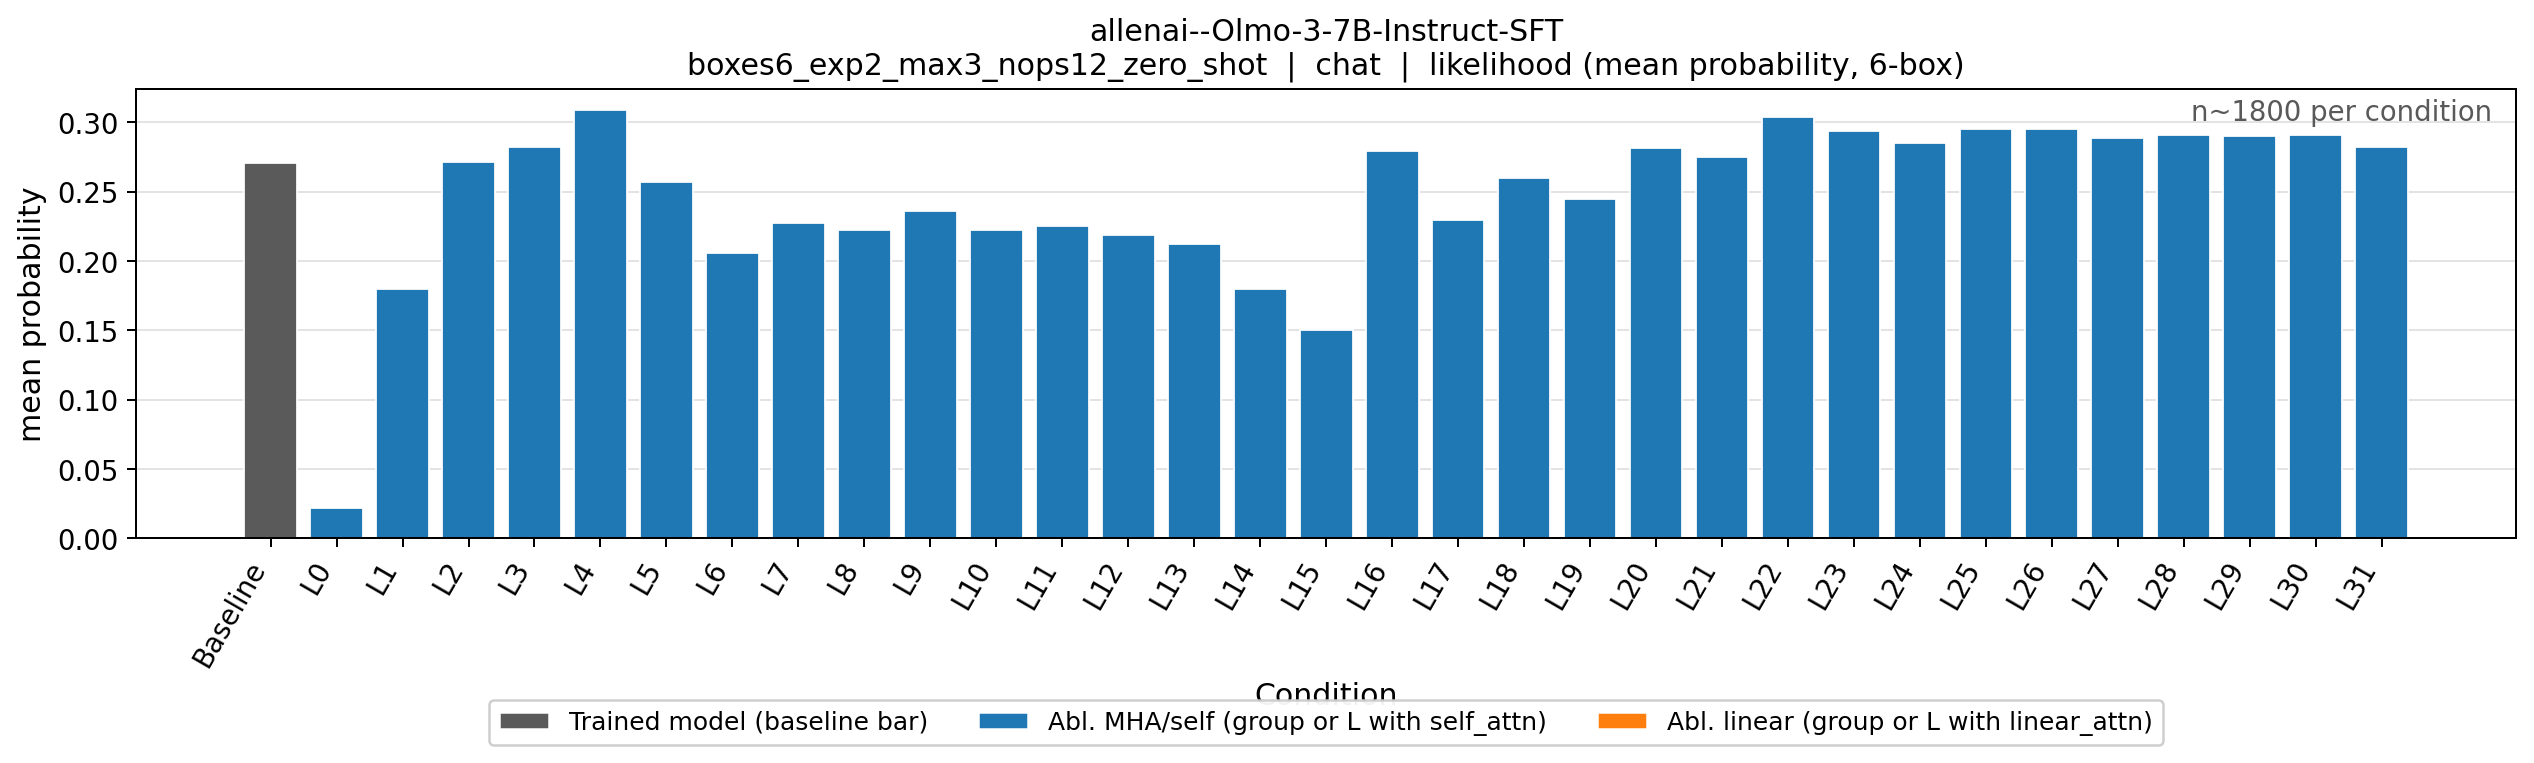

In [11]:
# Olmo Hybrid SFT: baseline vs trivial "nothing" constant vs group vs per-layer ablations
# fig_abl, ax_abl = plot_model_ablation_comparison_6box(
#     # "allenai/Olmo-Hybrid-Instruct-SFT-7B",
#     "Qwen--Qwen3.5-27B",
#     n_boxes=6,
#     prompt_mode="chat",
#     op_types="any",
#     metric="set_accuracy",
#     numops=None,  # e.g. 0, 1, … to restrict to that numops bin (requires `rows` in JSONs)
#     show_nothing_baseline=False,
# )
# plt.show()

# Likelihood example: compare two likelihood eval JSONs by numops bins.
# out_dir = task_root() / "output" / "boxes6_exp2_max3_nops12_zero_shot"
# fig_ll, ax_ll = plot_likelihood_pair_by_numops(
#     out_dir / "Qwen--Qwen3-32B_chat_likelihood.json",
#     out_dir / "Qwen--Qwen3.5-27B_chat_likelihood.json",
#     metric="probability",  # or "log_likelihood"
#     title="Qwen3 8B vs Qwen3.5 9B (likelihood)",
# )
# plt.show()

# Likelihood ablation example: one model, baseline/group/layer bars.
fig_abl_ll, ax_abl_ll = plot_model_ablation_likelihood_6box(
    "allenai--Olmo-3-7B-Instruct-SFT",
    n_boxes=6,
    prompt_mode="chat",
    metric="probability",  # or "probability"
)
plt.show()